SUPPORT VECTOR MACHINES (SVM)

Linear and RBF Kernels

Iris & Wine Datasets

In [ ]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

In [ ]:
#Load Datasets
iris = load_iris(as_frame=True)
wine = load_wine(as_frame=True)

df_iris = iris.frame
df_wine = wine.frame

df_iris.head(), df_wine.head()

(   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
 0                5.1               3.5                1.4               0.2   
 1                4.9               3.0                1.4               0.2   
 2                4.7               3.2                1.3               0.2   
 3                4.6               3.1                1.5               0.2   
 4                5.0               3.6                1.4               0.2   
 
    target  
 0       0  
 1       0  
 2       0  
 3       0  
 4       0  ,
    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
 0    14.23        1.71  2.43               15.6      127.0           2.80   
 1    13.20        1.78  2.14               11.2      100.0           2.65   
 2    13.16        2.36  2.67               18.6      101.0           2.80   
 3    14.37        1.95  2.50               16.8      113.0           3.85   
 4    13.24        2.59  2.87               21.0 

In [ ]:
#split the data
#Iris
X_i = df_iris.drop('target', axis=1)
y_i = df_iris['target']
X_i_tr, X_i_te, y_i_tr, y_i_te = train_test_split(X_i, y_i, test_size=0.2, random_state=42)

#wine
X_w = df_wine.drop('target', axis=1)
y_w = df_wine['target']
X_w_tr, X_w_te, y_w_tr, y_w_te = train_test_split(X_w, y_w, test_size=0.2, random_state=42)

In [ ]:
#SVM Linear Kernel
svm_lin = SVC(kernel='linear')
svm_lin.fit(X_i_tr, y_i_tr)
pred_lin=svm_lin.predict(X_i_te)

acc_lin = accuracy_score(y_i_te, pred_lin)
acc_lin, svm_lin.n_support_

(1.0, array([ 3, 11, 11], dtype=int32))

In [ ]:
#SVM RBF Kernel
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_i_tr, y_i_tr)
pred_rbf = svm_rbf.predict(X_i_te)

acc_rbf = accuracy_score(y_i_te, pred_rbf)
acc_rbf, svm_rbf.n_support_

(1.0, array([ 5, 26, 22], dtype=int32))

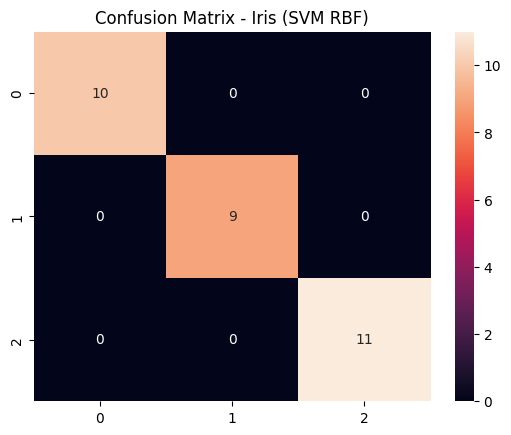

1.0

In [ ]:
#Confusion metric and f1_score for iris dataset
cm = confusion_matrix(y_i_te, pred_lin)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Iris (SVM RBF)")
plt.show()

f1_score(y_i_te, pred_rbf, average='macro')

In [ ]:
#logistic regression comparison
log = LogisticRegression(max_iter=5000)
log.fit(X_i_tr, y_i_tr)
pred_log = log.predict(X_i_te)

accuracy_score(y_i_te, pred_log)

1.0

In [ ]:
#KNN comparison
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_i_tr, y_i_tr)
pred_knn = knn.predict(X_i_te)

accuracy_score(y_i_te, pred_knn)


1.0

In [ ]:
#Model comparison table
results = pd.DataFrame({
    'Model': ['SVM Linear', 'SVM RBF', 'Logistic Regression', 'k-NN'],
    'Accuracy':[
        accuracy_score(y_i_te, pred_lin),
        accuracy_score(y_i_te, pred_rbf),
        accuracy_score(y_i_te, pred_log),
        accuracy_score(y_i_te, pred_knn)
    ]
})

results

,Model,Accuracy
0,SVM Linear,1.0
1,SVM RBF,1.0
2,Logistic Regression,1.0
3,k-NN,1.0


### Observations on SVM, Kernels, and Model Comparison

**1. Margins in SVM (Support Vector Machines):**

*   **Support Vectors:** The `n_support_` attribute for both linear and RBF kernels shows the number of support vectors found for each class. These are the data points closest to the decision boundary (margin), which are crucial for defining the hyperplane.
    *   For the **Linear Kernel SVM**, we observed `array([ 3, 11, 11])` support vectors, meaning 3 for class 0, 11 for class 1, and 11 for class 2. This indicates that these 25 points were critical in defining the linear decision boundaries.
    *   For the **RBF Kernel SVM**, we observed `array([ 5, 26, 22])` support vectors, meaning 5 for class 0, 26 for class 1, and 22 for class 2. The higher number of support vectors for the RBF kernel often implies a more complex decision boundary that can better capture non-linear relationships in the data, as it's trying to find optimal boundaries in a higher-dimensional space.
*   **Geometric Margin:** While not explicitly calculated, the concept of a 'margin' is central to SVMs. It refers to the distance between the decision hyperplane and the nearest data point from either class (the support vectors). A larger margin generally indicates better generalization capability.

**2. Performance of Linear vs. RBF Kernels (Iris Dataset):**

*   Both the **Linear Kernel SVM** and the **RBF Kernel SVM** achieved an accuracy of `1.0` (100%) on the Iris test dataset. This suggests that for the Iris dataset, which is relatively separable, both kernels were highly effective in classifying the data.
*   The **Confusion Matrix** for the RBF kernel also showed perfect classification, with all off-diagonal elements being zero, further confirming its excellent performance. The **F1-score** for the RBF kernel was also `1.0`, indicating perfect precision and recall.
*   The Iris dataset is known to be relatively easy to classify, especially the 'setosa' class. The other two classes ('versicolor' and 'virginica') are slightly more overlapping but still manageable for these models.

**3. Model Comparison (Iris Dataset):**

*   When comparing **SVM (Linear and RBF)** with **Logistic Regression** and **k-Nearest Neighbors (k-NN)** on the Iris dataset, all models achieved a perfect accuracy of `1.0`.
*   **Results Table:**

| Model                 | Accuracy |
| :-------------------- | :------- |
| SVM Linear            | 1.0      |
| SVM RBF               | 1.0      |
| Logistic Regression   | 1.0      |
| k-NN                  | 1.0      |

*   This indicates that for the given split of the Iris dataset, all tested classification algorithms were able to perfectly distinguish between the classes.
*   In a real-world scenario with a more complex dataset, differences in performance between these models would likely become more apparent, and factors like computational cost, interpretability, and hyperparameter tuning would play a more significant role in model selection.
*   The fact that multiple models achieve perfect accuracy on this dataset highlights its relatively straightforward separability.